{0: 0, 1: 0, 2: 0, 3: 0, 4: 3, 5: 3}
{0}


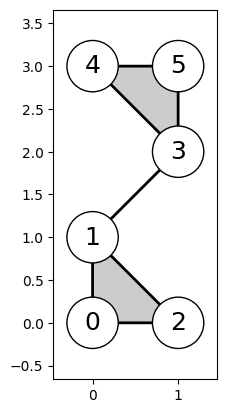

In [35]:
import matplotlib.pyplot as plt

def drawComplex(P,K, ax, tc='#ccc'):

    # draw triangles
    for i,s in enumerate(K):
        if len(s)==3:
            polygon = plt.Polygon(
                [P[s[0]],P[s[1]],P[s[2]]],
                facecolor=tc,
                edgecolor='black',
                lw=2,
                zorder=0
            )
            ax.add_patch(polygon)

    # draw edges
    for i,s in enumerate(K):
        if len(s)==2:
            line = plt.Line2D(
                [P[s[0]][0],P[s[1]][0]],
                [P[s[0]][1],P[s[1]][1]],
                c='black',lw=2,zorder=1)
            ax.add_line(line)

    # draw vertices
    for i,p in enumerate(P):
        circle = plt.Circle(p, radius=0.3, fc='w',ec='black',zorder=2)
        ax.add_patch(circle)
        plt.text(p[0], p[1], str(i),ha="center", va="center", color="black",size=18)

    plt.margins(0.1)
    ax.set_aspect('equal', 'box')


P = [
    (0,0), (0,1), (1,0),
    (1,2), (0,3), (1,3),
]
K = [
    (0,1,2),
    (3,4,5),
    (1,3)
]


def getEdges(K):
    edges = set({})
    for s in K:
        if len(s)==1:
            continue
        elif len(s)==2:
            edges.add( (min(s[0],s[1]), max(s[0],s[1])) )
        elif len(s)==3:
            edges.add( (min(s[0],s[1]), max(s[0],s[1])) )
            edges.add( (min(s[1],s[2]), max(s[1],s[2])) )
            edges.add( (min(s[0],s[2]), max(s[0],s[2])) )
    return edges

def union_find(P,K):
    
    vertexToParent = {}
    for i,p in enumerate(P):
        vertexToParent[i] = i
    
    edges = getEdges(K)
    for e in edges:
        # find
        x = e[0]
        while x!=vertexToParent[x]:
            x = vertexToParent[x]
        
        # find
        y = e[1]
        while y!=vertexToParent[y]:
            y = vertexToParent[y]
            
        # union
        vertexToParent[y] = x
    
    return vertexToParent


ax = plt.axes()
drawComplex(P,K, ax)

sets = union_find(P,K)
print(sets)

keys = set()
for i in sets:
    x = i
    while x!=sets[x]:
        x = sets[x]
    keys.add(x)
print(keys)